# 6CS012 - Worksheet 5: End-to-End CNN Model for Image Classification
### Fruit Classification using TensorFlow & Keras
---

## Setup: Install Required Libraries

## Import Libraries

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.19.0
Libraries imported successfully!


---
## Task 1: Data Understanding and Visualization

### 1.1 Load and Visualize Images from the Dataset

In [ ]:

train_dir = '/content/drive/MyDrive/AI And ML/FruitinAmazon/FruitinAmazon/test'
test_dir  = '/content/drive/MyDrive/AI And ML/FruitinAmazon/FruitinAmazon/train'

# Get the list of class directories
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Number of classes found: {len(class_dirs)}")
print(f"Classes: {class_dirs}")

Number of classes found: 6
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


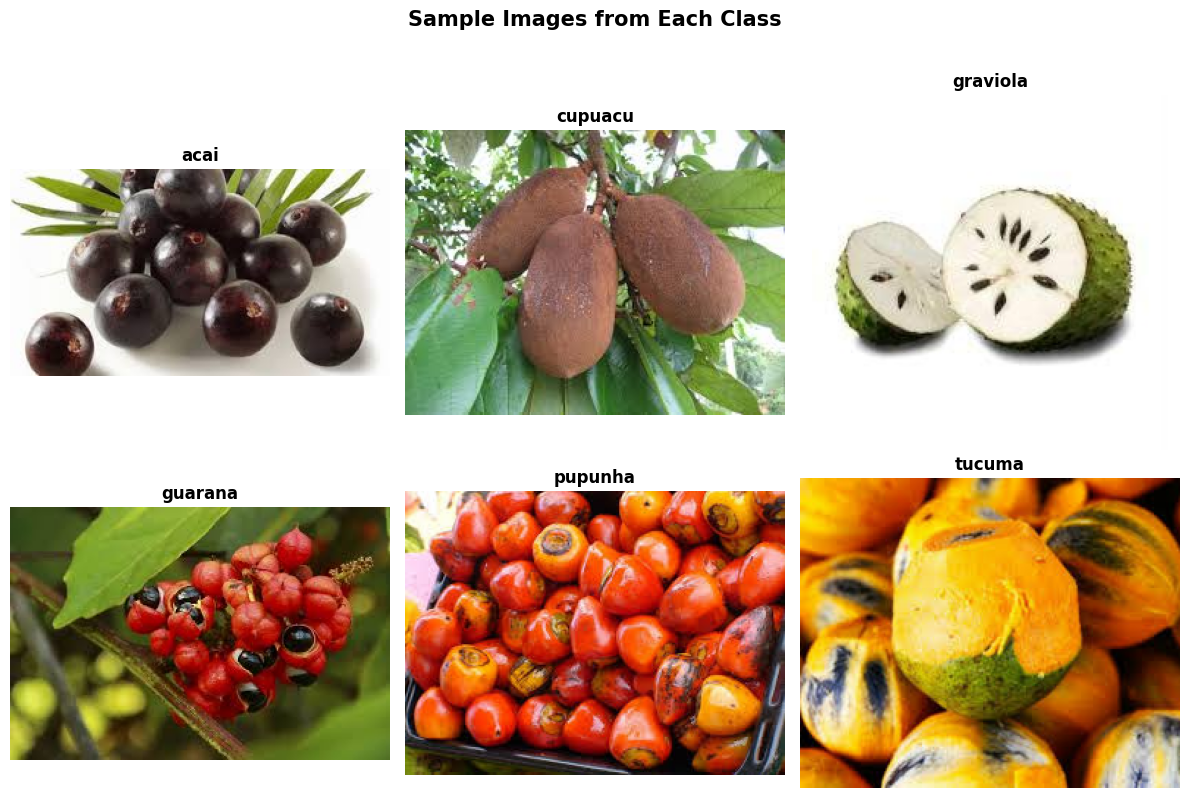

✅ Figure saved as 'sample_images.png'


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Filter only classes that actually contain images
valid_classes = []

for class_name in class_dirs:
    class_path = os.path.join(train_dir, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    if len(images) > 0:
        valid_classes.append(class_name)
    else:
        print(f"⚠️ Skipping empty class: {class_name}")

num_classes = len(valid_classes)

# Grid setup
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

# Plot images
for idx, class_name in enumerate(valid_classes):
    class_path = os.path.join(train_dir, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

    chosen_image = random.choice(images)
    img_path = os.path.join(class_path, chosen_image)

    img = Image.open(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(num_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('sample_images.png', bbox_inches='tight')
plt.show()

print("✅ Figure saved as 'sample_images.png'")

**Observation:**  
The dataset contains images of Amazonian fruits. Each class (e.g., acai, guarana, graviola, tucuma, pupunha, cupuacu) shows distinct visual characteristics — different colours, textures, shapes, and sizes. The images vary in resolution and background, which presents a realistic classification challenge. A CNN is well-suited to learn these spatial features automatically through its convolutional layers.

### 1.2 Check for Corrupted Images

In [ ]:
corrupted_images = []

for class_name in class_dirs:
    class_path = os.path.join(train_dir, class_name)
    for fname in os.listdir(class_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            continue
        image_path = os.path.join(class_path, fname)
        try:
            with Image.open(image_path) as img:
                img.verify()   # Checks file integrity without fully loading
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


---
## Task 2: Loading and Preprocessing Image Data

In [ ]:
# Hyperparameters
IMG_HEIGHT      = 128
IMG_WIDTH       = 128
BATCH_SIZE      = 16      # as required by Task 4 (batch_size=16)
VALIDATION_SPLIT = 0.2    # 80% train, 20% validation
SEED            = 123

# Normalisation layer (rescale pixel values from [0,255] to [0,1])
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ---- Training Dataset ----
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=SEED
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ---- Validation Dataset ----
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=SEED
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Class names (inferred from directory names using class_dirs)
class_names = class_dirs # Use the already defined class_dirs
num_classes = len(class_names)
print(f"Class names : {class_names}")
print(f"Num classes : {num_classes}")

Found 30 files belonging to 6 classes.
Using 24 files for training.
Found 30 files belonging to 6 classes.
Using 6 files for validation.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


In [ ]:
# ---- Test Dataset (if a separate test folder is available) ----
# If you do not have a separate test folder, use val_ds for evaluation.
try:
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
    print("Separate test dataset loaded.")
except Exception:
    test_ds = val_ds
    print("No separate test folder found — using validation set as test set.")

Found 90 files belonging to 6 classes.
Separate test dataset loaded.


---
## Task 3: Implement the CNN Architecture

In [ ]:
def build_cnn(input_shape, num_classes):
    """
    CNN architecture as specified in the worksheet:
      Conv2D(32, 3x3, same, relu) -> MaxPool(2x2)
      Conv2D(32, 3x3, same, relu) -> MaxPool(2x2)
      Flatten -> Dense(64, relu) -> Dense(128, relu)
      Output Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        # ----- Convolutional Block 1 -----
        layers.Conv2D(
            filters=32, kernel_size=(3, 3),
            padding='same', strides=1,
            input_shape=input_shape
        ),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),

        # ----- Convolutional Block 2 -----
        layers.Conv2D(
            filters=32, kernel_size=(3, 3),
            padding='same', strides=1
        ),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2),

        # ----- Fully Connected Network -----
        layers.Flatten(),

        # Hidden Layer 1 (Input Layer of FCN)
        layers.Dense(64, activation='relu'),

        # Hidden Layer 2
        layers.Dense(128, activation='relu'),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ], name='Fruit_CNN')

    return model


input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)  # RGB images
model = build_cnn(input_shape, num_classes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## Task 4: Compile and Train the Model

In [ ]:
# ---- Compile ----
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
import os

# ---- Callbacks ----
checkpoint_path = 'best_model.h5'

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,          # stop if val_loss doesn't improve for 20 epochs
    restore_best_weights=True,
    verbose=1
)

# ---- Train ----
EPOCHS = 250

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

print("\nTraining complete!")

Epoch 1/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1250 - loss: 1.8890
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.1250 - loss: 1.9842 - val_accuracy: 0.3333 - val_loss: 1.4895
Epoch 2/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3125 - loss: 1.6108
Epoch 2: val_accuracy improved from 0.33333 to 0.50000, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2917 - loss: 1.6856 - val_accuracy: 0.5000 - val_loss: 1.5088
Epoch 3/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4479 - loss: 1.5319
Epoch 3: val_accuracy did not improve from 0.50000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.4583 - loss: 1.5464 - val_accuracy: 0.3333 - val_loss: 1.5162
Epoch 4/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6250 - loss: 1.4193
Epoch 4: val_accuracy did not improve from 0.50000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5833 - loss: 1.3667 - val_accuracy: 0.1667 - val_loss: 1.4493
Epoch 5/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5000 - loss: 1.2550
Epoch 5: val_accuracy improved from 0.50000 to 0.66667, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.6250 - loss: 1.1475 - val_accuracy: 0.6667 - val_loss: 1.1700
Epoch 6/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8750 - loss: 0.8592
Epoch 6: val_accuracy did not improve from 0.66667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7500 - loss: 0.9433 - val_accuracy: 0.6667 - val_loss: 0.8380
Epoch 7/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8229 - loss: 0.6761
Epoch 7: val_accuracy improved from 0.66667 to 1.00000, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8333 - loss: 0.6730 - val_accuracy: 1.0000 - val_loss: 0.6212
Epoch 8/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.4801
Epoch 8: val_accuracy did not improve from 1.00000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.4076 - val_accuracy: 0.8333 - val_loss: 0.6885
Epoch 9/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.2585
Epoch 9: val_accuracy did not improve from 1.00000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 1.0000 - loss: 0.2510 - val_accuracy: 1.0000 - val_loss: 0.2266
Epoch 10/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.1639
Epoch 10: val_accuracy did not improve from 1.00000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.1520 - val_accuracy: 1.0000 - val_loss: 0.0632
Epoch 11/250
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0868
E

### Training & Validation Curves

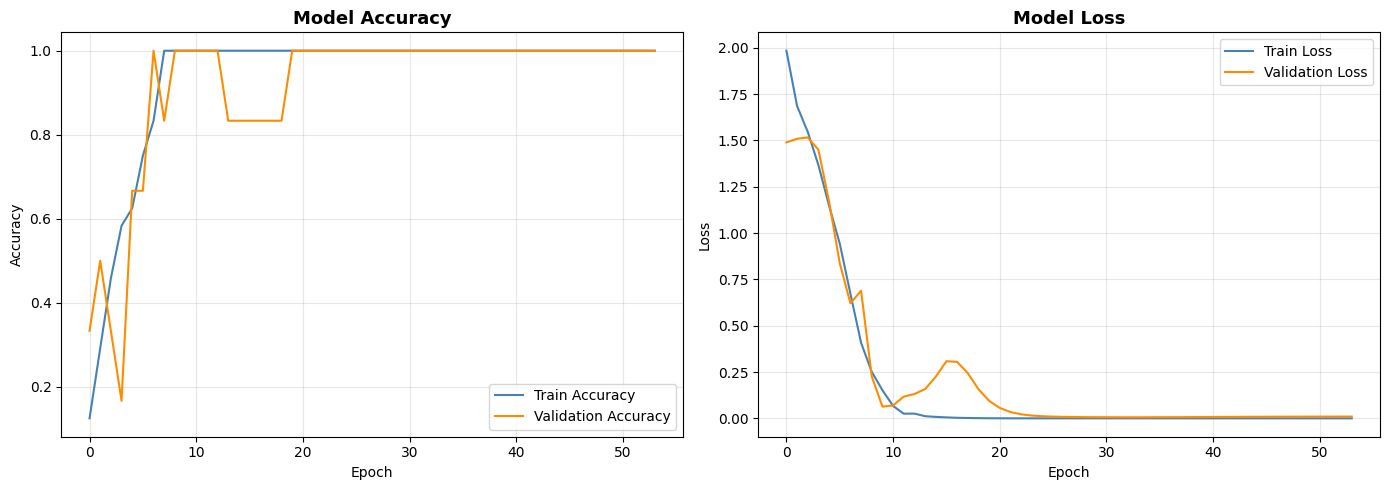

Figure saved as 'training_curves.png'


In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Accuracy ---
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
    axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- Loss ---
    axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
    axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved as 'training_curves.png'")

plot_history(history)

---
## Task 5: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.5111 - loss: 2.4950

Test Loss     : 2.4950
Test Accuracy : 0.5111 (51.11%)


---
## Task 6: Save and Load the Model

In [ ]:
# ---- Save the final trained model ----
save_path = 'fruit_cnn_model.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: fruit_cnn_model.h5


In [ ]:
# ---- Load and re-evaluate ----
loaded_model = keras.models.load_model(save_path)
print("Model loaded successfully!")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model — Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy : {loaded_acc:.4f} ({loaded_acc*100:.2f}%)")

Model loaded successfully!
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5111 - loss: 2.4950

Loaded Model — Test Loss     : 2.4950
Loaded Model — Test Accuracy : 0.5111 (51.11%)


---
## Task 7: Predictions and Classification Report

In [ ]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)

    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities → class indices
y_pred = np.argmax(y_pred_probs, axis=1)

print("✅ Predictions collected.")
print(f"Total samples evaluated: {len(y_true)}")

✅ Predictions collected.
Total samples evaluated: 90


In [ ]:
from sklearn.metrics import classification_report

# Ensure class_names exists
# The class_names variable is already correctly defined using class_dirs globally.
# class_names = test_ds.class_names # This line is no longer needed and causes an AttributeError.

# Safety check: match number of classes
num_classes = len(class_names)

print("\nClassification Report")
print("=" * 60)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    labels=range(num_classes),   # ensures alignment
    zero_division=0              # avoids division errors
))


Classification Report
              precision    recall  f1-score   support

        acai       0.65      0.73      0.69        15
     cupuacu       0.83      0.33      0.48        15
    graviola       0.75      1.00      0.86        15
     guarana       0.33      0.53      0.41        15
     pupunha       0.24      0.27      0.25        15
      tucuma       0.50      0.20      0.29        15

    accuracy                           0.51        90
   macro avg       0.55      0.51      0.49        90
weighted avg       0.55      0.51      0.49        90



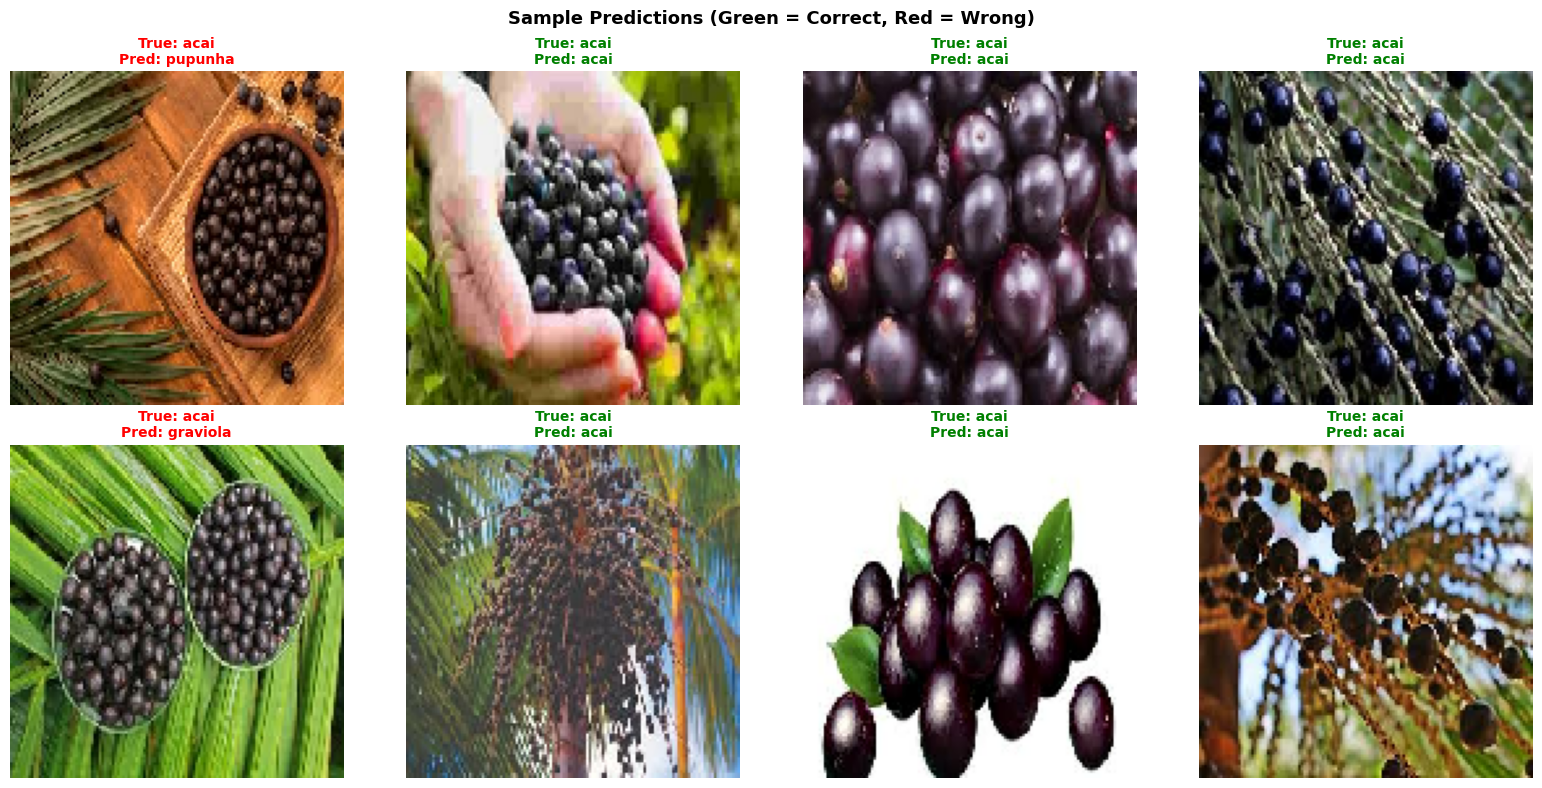

Figure saved as 'sample_predictions.png'


In [ ]:
# ---- Visualise a few predictions ----
# Add the definition of class_names using the globally available class_dirs
class_names = class_dirs

sample_images, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images, verbose=0), axis=1)

n_show = min(8, len(sample_images))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    img = sample_images[i].numpy()
    true_label = class_names[sample_labels[i].numpy()]
    pred_label = class_names[sample_preds[i]]
    color = 'green' if true_label == pred_label else 'red'

    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=10, color=color, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'sample_predictions.png'")

---
## Summary of Deliverables

| Deliverable | File |
|---|---|
| Full code implementation | This notebook |
| Training & validation curves | `training_curves.png` |
| Sample class images | `sample_images.png` |
| Sample predictions | `sample_predictions.png` |
| Best model (saved during training) | `best_model.h5` |
| Final trained model | `fruit_cnn_model.h5` |
| Classification report | Printed above |